In [1]:
import numpy as np

m0 = 1.919e-2
T0 = 273
S0 = 139

f = lambda T: m0*(1000*T/T0)**(3/2)*((T0 + S0) / (1000*T + S0))

In [2]:
X =  [0.273, 0.303, 0.323, 0.353, 0.423, 0.573, 1.473]
Y = []

for x in X:
    Y.append(f(x))
print(X)
print(Y)

[0.273, 0.303, 0.323, 0.353, 0.423, 0.573, 1.473]
[0.01919, 0.020915579100108536, 0.022023687096322853, 0.023627902795891973, 0.027133289945188273, 0.033766042247938485, 0.061470578884165926]


In [3]:
f(1.2)

0.05441511010432762

In [4]:
X =  [0.273, 0.473, 0.673, 0.873, 1.073, 1.273, 1.473]
Y = []

for x in X:
    Y.append(f(x))
print(X)
print(Y)

[0.273, 0.473, 0.673, 0.873, 1.073, 1.273, 1.473]
[0.01919, 0.029462426301269433, 0.03768727939346143, 0.04467546415145605, 0.050830593822385466, 0.05638143549190039, 0.061470578884165926]


In [5]:
X = []
Y = []
x = 0.273
dx = 0.05
while(x < 1.673):
    X.append(x)
    Y.append(f(x))
    x += dx

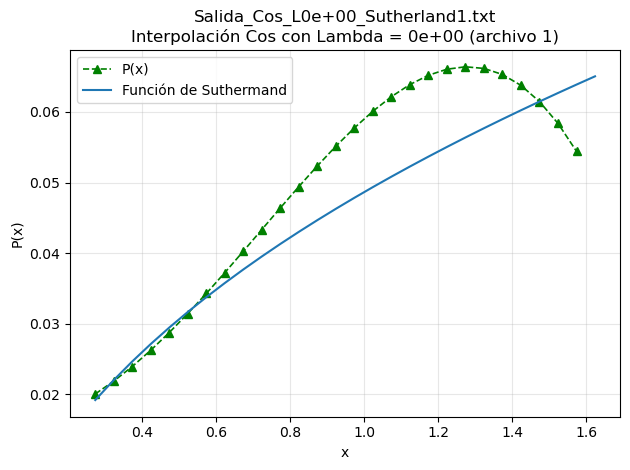

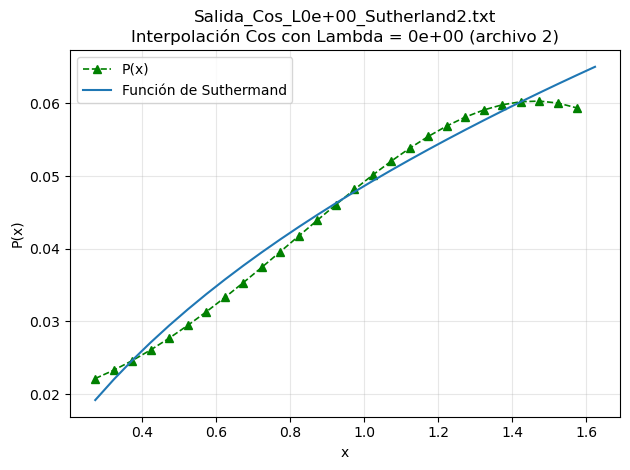

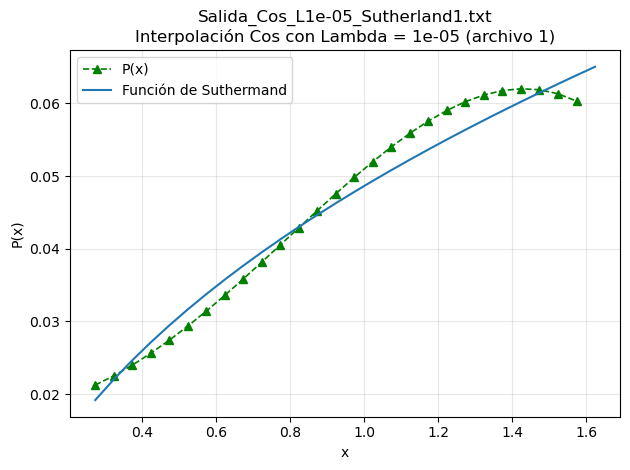

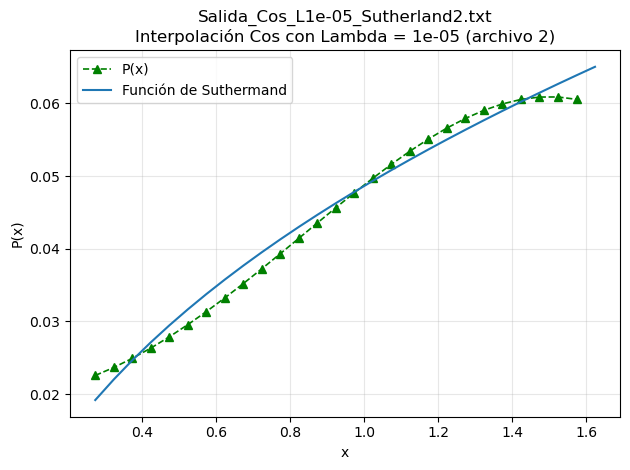

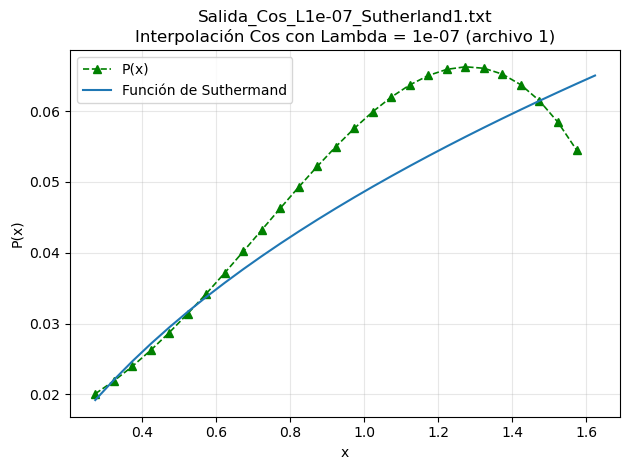

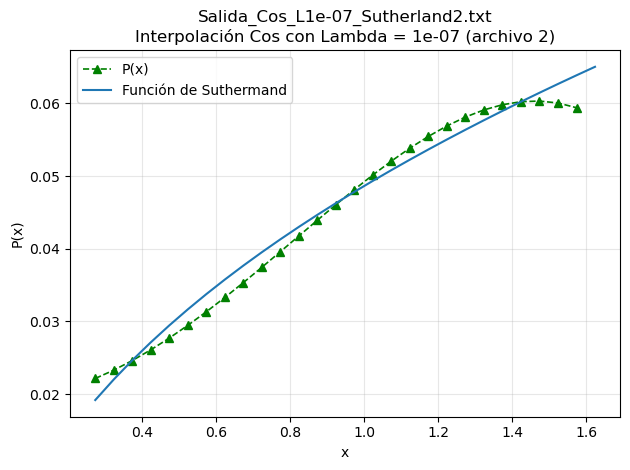

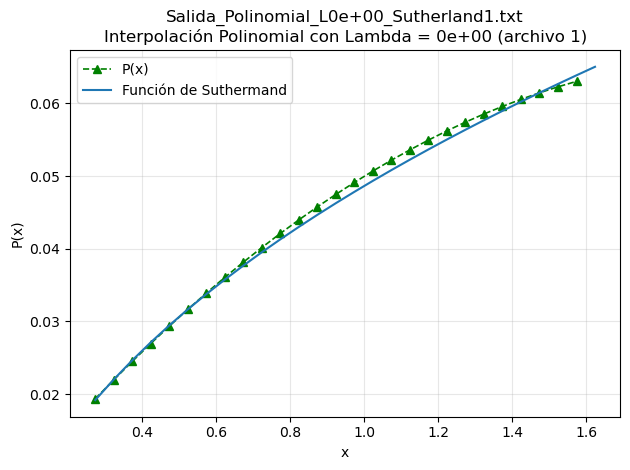

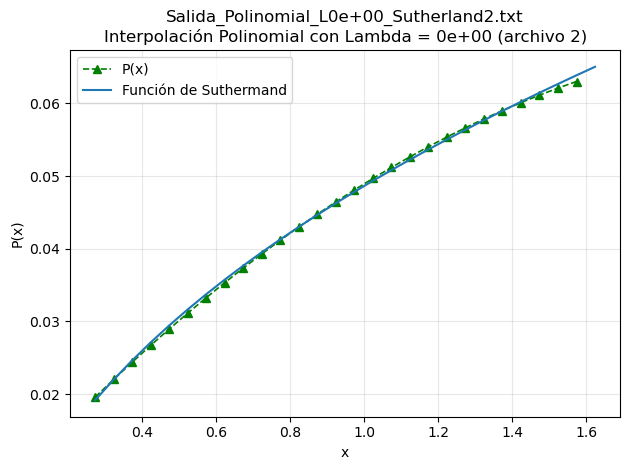

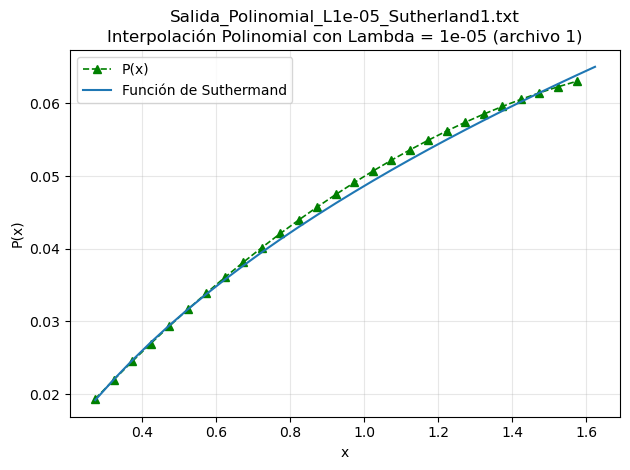

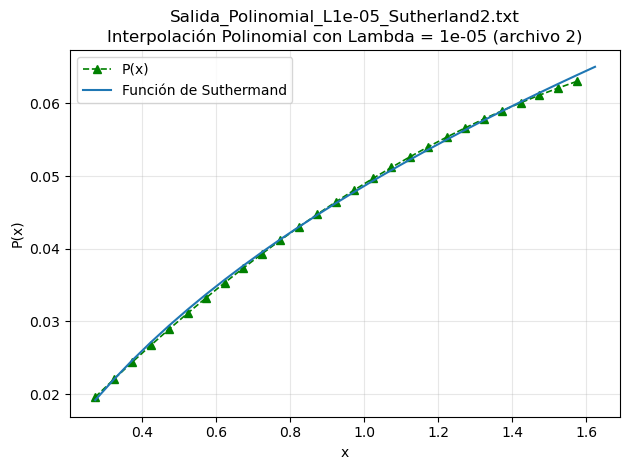

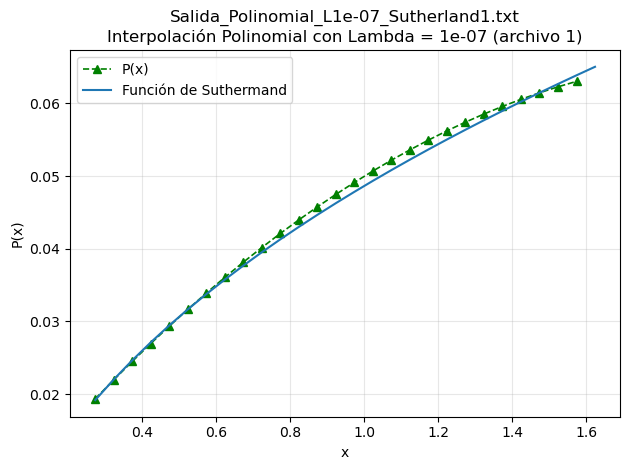

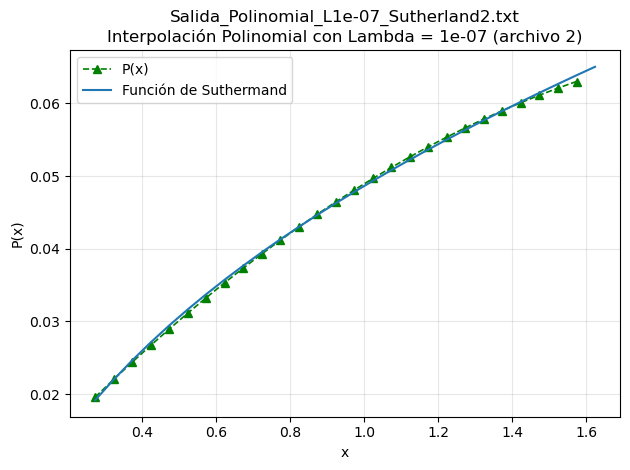

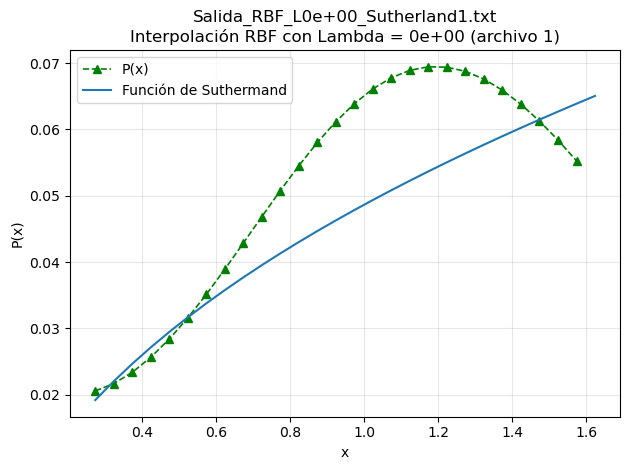

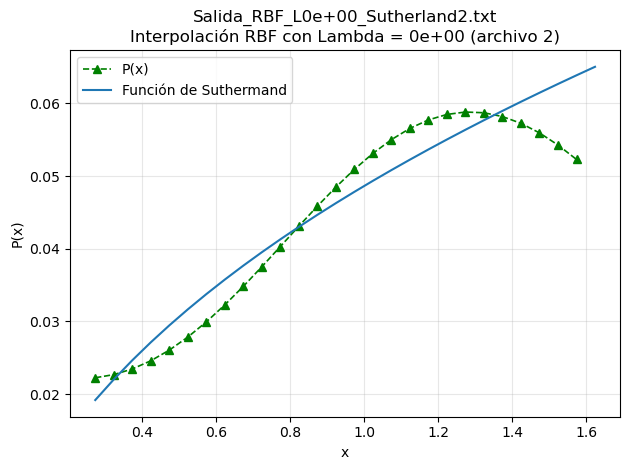

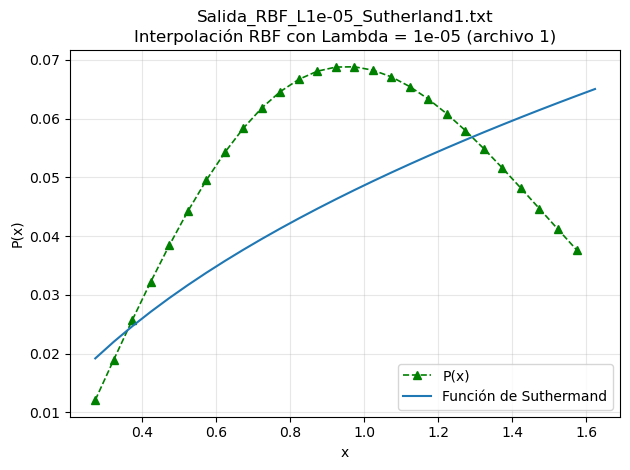

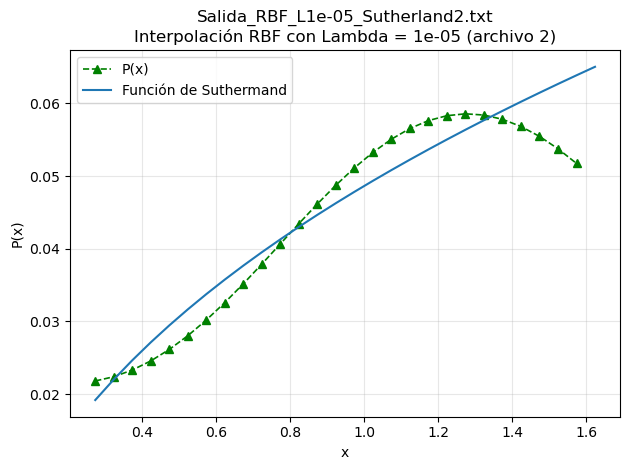

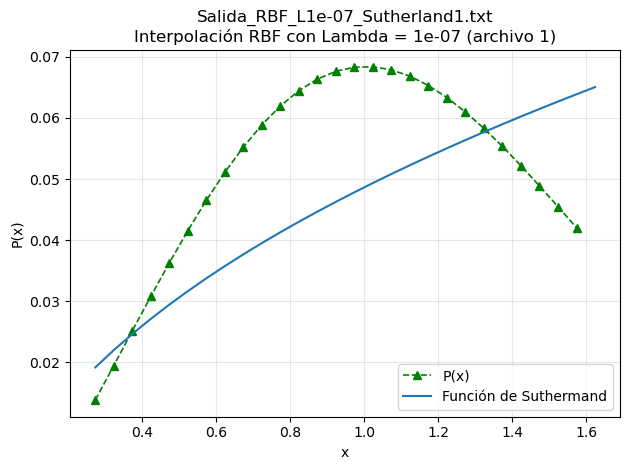

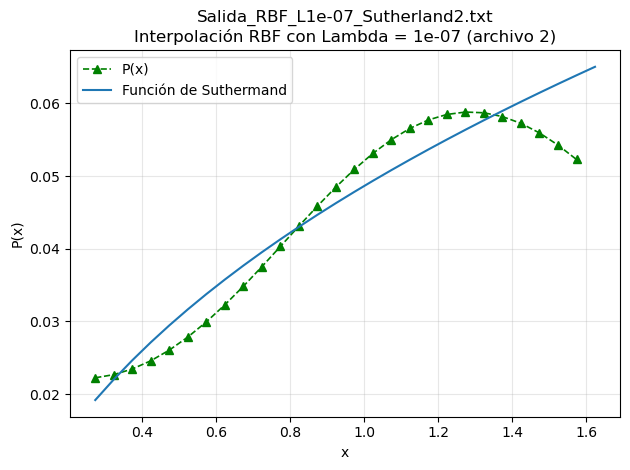

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os

CARPETA = "."                  
PATRON = "Salida_*.txt"        
GUARDAR_PNG = False            
SALIDA_IMAGENES_FOLDER = "plots"
os.makedirs(SALIDA_IMAGENES_FOLDER, exist_ok=True)

archivos = sorted(glob.glob(os.path.join(CARPETA, PATRON)))
if not archivos:
    raise FileNotFoundError(f"No se encontraron archivos con patrón: {PATRON}")

for archivo in archivos:
    with open(archivo, "r", encoding="utf-8") as f:
        lines = [ln.strip() for ln in f if ln.strip() and not ln.startswith("#")]
    title = lines[0] if lines else os.path.basename(archivo)

    df = pd.read_csv(
        archivo,
        comment="#",
        sep=r'\s+',
        names=["x", "P(x)"],
        usecols=[0, 1],
        engine='python'
    )

    df["x"] = pd.to_numeric(df["x"], errors='coerce')
    df["P(x)"] = pd.to_numeric(df["P(x)"], errors='coerce')
    df = df.dropna().sort_values("x").reset_index(drop=True)

    ax = df.plot(
        x="x",
        y="P(x)",
        kind="line",
        marker="^",
        linestyle="--",
        color="green",
        linewidth=1.2,
        title=f"{os.path.basename(archivo)}\n{title}"
    )

    
    ax.plot(X, Y, label="Función de Suthermand")
    ax.set_xlabel("x")
    ax.set_ylabel("P(x)")
    ax.grid(alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()